## Structural Phase Classification for End-to-End Evaluation

This notebook trains an XGBoost phase classifier using the structural
training pool defined by the fixed Li-air outer split.

### Workflow

1. Load the structural training pool and matching outer-test records.
2. Fit a scaler on training data and select the top 15 features.
3. Train the final classifier and evaluate outer-test predictions.
4. Save the classifier, preprocessing objects, and ROC curve data.
5. Run five-fold compound-grouped cross-validation using a separate
   classifier configuration and a threshold of 0.62.

Scaling and feature selection are performed before cross-validation.
The CV settings differ from those of the saved final classifier.
This notebook does not export out-of-fold predictions for downstream use.
Run after structural data splitting, with cells executed sequentially.

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GroupKFold

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [2]:
#  Load the fixed training and outer-test datasets
train_data = pd.read_csv(
    "data/end_to_end_split/structure/label_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/label_air_test.csv"
)


#  Define features and labels
X_train = train_data.drop(
    columns=["label", "compound"]
)

y_train = train_data["label"].astype(int)

X_test = test_data.drop(
    columns=["label", "compound"]
)

y_test = test_data["label"].astype(int)


# Standardize features
scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)


#  Save the scaler
SAVE_DIR = "data/end_to_end_predictions/structure/label"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    scaler,
    os.path.join(SAVE_DIR, "label_scaler.pkl")
)


#  Save the feature order
pd.DataFrame({
    "feature": X_train.columns
}).to_csv(
    os.path.join(SAVE_DIR, "label_feature_names.csv"),
    index=False
)


# Check the datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Train compounds:", train_data["compound"].nunique())
print("Test compounds:", test_data["compound"].nunique())

print("Train label distribution:")
print(y_train.value_counts().sort_index())

print("Test label distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (138, 25)
X_test shape: (22, 25)
Train compounds: 135
Test compounds: 21
Train label distribution:
0    91
1    47
Name: label, dtype: int64
Test label distribution:
0    14
1     8
Name: label, dtype: int64


In [3]:
# ============================================================
# Train the initial XGBoost classifier
# ============================================================

clf_selector = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    reg_alpha=1,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)

clf_selector.fit(
    X_train_scale,
    y_train
)


# ============================================================
#  Extract feature importance
# ============================================================

feature_importance = (
    clf_selector.feature_importances_
)

feature_names = (
    X_train.columns.to_numpy()
)

num_features_to_keep = 15

top_idx = np.argsort(
    feature_importance
)[::-1][:num_features_to_keep]

selected_features = (
    feature_names[top_idx]
    .tolist()
)

print("Selected features:")
print(selected_features)


# ============================================================
# Select training and outer-test features
# ============================================================

X_train_selected = (
    X_train_scale[:, top_idx]
)

X_test_selected = (
    X_test_scale[:, top_idx]
)

print(
    "Selected training shape:",
    X_train_selected.shape
)

print(
    "Selected outer-test shape:",
    X_test_selected.shape
)


# ============================================================
#  Save selected feature information
# ============================================================

SAVE_DIR = (
    "data/end_to_end_predictions/"
    "structure/label"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

with open(
    os.path.join(
        SAVE_DIR,
        "label_selected_features.json"
    ),
    "w"
) as file:
    json.dump(
        selected_features,
        file,
        indent=2
    )

np.save(
    os.path.join(
        SAVE_DIR,
        "label_selected_feature_indices.npy"
    ),
    top_idx
)

Selected features:
['C_EA', 'AB_AN', 'AB_AR', 'AB_FIE', 'AB_SIE', 'C_FIE', 'AB_CR', 'AB_EN', 'AB_EA', 'AB_TC', 'AB_Nv', 'AB_AW', 'AB_EC', 'C_AN', 'C_CR']
Selected training shape: (138, 15)
Selected outer-test shape: (22, 15)


[09:11:17] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Classification report:
              precision    recall  f1-score   support

           0      0.857     0.857     0.857        14
           1      0.750     0.750     0.750         8

    accuracy                          0.818        22
   macro avg      0.804     0.804     0.804        22
weighted avg      0.818     0.818     0.818        22



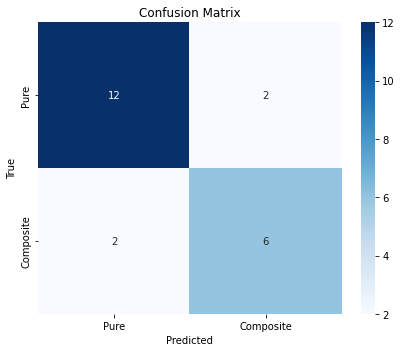

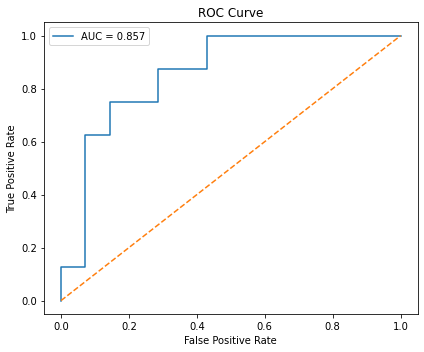

Outer-test ROC-AUC: 0.8571


In [4]:
# ============================================================
#  Train the final classifier
# ============================================================

clf = XGBClassifier(
    max_depth=5,      
    n_estimators=150,  
    learning_rate=0.01,
    reg_alpha=1,
    reg_lambda=1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=2027
)

clf.fit(
    X_train_selected,
    y_train
)


# ============================================================
#  Predict the outer-test dataset
# ============================================================

threshold = 0.55

y_proba = clf.predict_proba(
    X_test_selected
)[:, 1]

y_pred = (
    y_proba >= threshold
).astype(int)


# ============================================================
#  Print the classification report
# ============================================================

print("Classification report:")

print(
    classification_report(
        y_test,
        y_pred,
        digits=3,
        zero_division=0
    )
)


# ============================================================
#  Plot the confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Pure",
        "Composite"
    ],
    yticklabels=[
        "Pure",
        "Composite"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
#  Plot the ROC curve
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

auc_score = roc_auc_score(
    y_test,
    y_proba
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Outer-test ROC-AUC:",
    round(auc_score, 4)
)


In [5]:
# ============================================================
# Save the ROC curve data
# ============================================================

import os

os.makedirs(
    "result",
    exist_ok=True
)

roc_data = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr
})

roc_data["ROC_AUC"] = auc_score

roc_data.to_csv(
    "result/roc_curve_data.csv",
    index=False
)

print(
    "ROC curve data saved to: "
    "result/roc_curve_data.csv"
)

ROC curve data saved to: result/roc_curve_data.csv


In [6]:
joblib.dump(clf, "model/end to end/xgb_classifier.pkl")
joblib.dump(scaler, "model/end to end/label_scaler.pkl")
np.save("model/end to end/label_top_idx.npy", top_idx)

In [7]:
groups = train_data["compound"]

cv = GroupKFold(n_splits=5)

cv_results = []

threshold = 0.62


for fold, (train_idx, valid_idx) in enumerate(
    cv.split(
        X_train_selected,
        y_train,
        groups=groups
    ),
    start=1
):

    X_fold_train = X_train_selected[train_idx]
    X_fold_valid = X_train_selected[valid_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        max_depth=3,
        n_estimators=200,
        learning_rate=0.05,
        reg_alpha=1,
        reg_lambda=1,
        scale_pos_weight=(
            (y_fold_train == 0).sum()
            / (y_fold_train == 1).sum()
        ),
        random_state=42
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    y_fold_proba = model.predict_proba(
        X_fold_valid
    )[:, 1]

    y_fold_pred = (
        y_fold_proba >= threshold
    ).astype(int)

    cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(
            y_fold_valid,
            y_fold_pred
        ),
        "Precision": precision_score(
            y_fold_valid,
            y_fold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_fold_valid,
            y_fold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_fold_valid,
            y_fold_pred,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_fold_valid,
            y_fold_proba
        )
    })


cv_results = pd.DataFrame(cv_results)

print(cv_results)

print("\n5-fold CV mean:")
print(
    cv_results.iloc[:, 1:].mean()
)

print("\n5-fold CV standard deviation:")
print(
    cv_results.iloc[:, 1:].std()
)

   Fold  Accuracy  Precision    Recall        F1       AUC
0     1  0.607143   0.461538  0.600000  0.521739  0.625000
1     2  0.607143   0.333333  0.571429  0.421053  0.595238
2     3  0.607143   0.714286  0.357143  0.476190  0.780612
3     4  0.814815   0.600000  0.500000  0.545455  0.785714
4     5  0.851852   0.875000  0.700000  0.777778  0.929412

5-fold CV mean:
Accuracy     0.697619
Precision    0.596832
Recall       0.545714
F1           0.548443
AUC          0.743195
dtype: float64

5-fold CV standard deviation:
Accuracy     0.124580
Precision    0.211494
Recall       0.127536
F1           0.136716
AUC          0.135781
dtype: float64
